# Module 3: Dialogue Summarization
### Fine-Tuning BART-base on SAMSum + DialogSum

## Install Packages

In [1]:
!pip install datasets==2.18.0 transformers accelerate sentencepiece
!pip install evaluate rouge_score
!pip install pandas matplotlib seaborn tqdm
!pip install numpy==1.26.4

## Import Libraries

In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import evaluate
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")
set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

BASE_DIR = Path("./nlu_models")
BASE_DIR.mkdir(exist_ok=True)

SUMM_DIR = BASE_DIR / "summarizer"
SUMM_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
print(f"Model will be saved in: {SUMM_DIR.absolute()}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Model will be saved in: /content/nlu_models/summarizer


## 3.1 Load & Explore SAMSum + DialogSum

In [3]:
print("Loading SAMSum dataset")
ds_samsum = load_dataset("knkarthick/samsum", trust_remote_code=True)
print(ds_samsum)

print("\nLoading DialogSum dataset")
ds_dialogsum = load_dataset("knkarthick/dialogsum", trust_remote_code=True)
print(ds_dialogsum)

Loading SAMSum dataset


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

Loading DialogSum dataset


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 12460
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 500
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1500
    })
})


In [4]:
print("SAMSum sample:")
display(pd.DataFrame(ds_samsum["train"].select(range(2)))[["dialogue", "summary"]])

print("\nDialogSum sample:")
display(pd.DataFrame(ds_dialogsum["train"].select(range(2)))[["dialogue", "summary"]])

SAMSum sample:


,dialogue,summary
0,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...



DialogSum sample:


,dialogue,summary
0,"#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. ...","Mr. Smith's getting a check-up, and Doctor Haw..."
1,"#Person1#: Hello Mrs. Parker, how have you bee...",Mrs Parker takes Ricky for his vaccines. Dr. P...


## 3.2 EDA — Summarization

In [5]:
df_sam = pd.DataFrame(ds_samsum["train"])
df_dia = pd.DataFrame(ds_dialogsum["train"])

for df, name in [(df_sam, "SAMSum"), (df_dia, "DialogSum")]:
    df["dialogue_len"] = df["dialogue"].str.split().str.len()
    df["summary_len"]  = df["summary"].str.split().str.len()
    df["compression"]  = df["dialogue_len"] / df["summary_len"].clip(lower=1)
    print(f"{name}: {len(df):,} train samples | avg dialogue: {df['dialogue_len'].mean():.0f} words")

SAMSum: 14,731 train samples | avg dialogue: 94 words
DialogSum: 12,460 train samples | avg dialogue: 131 words


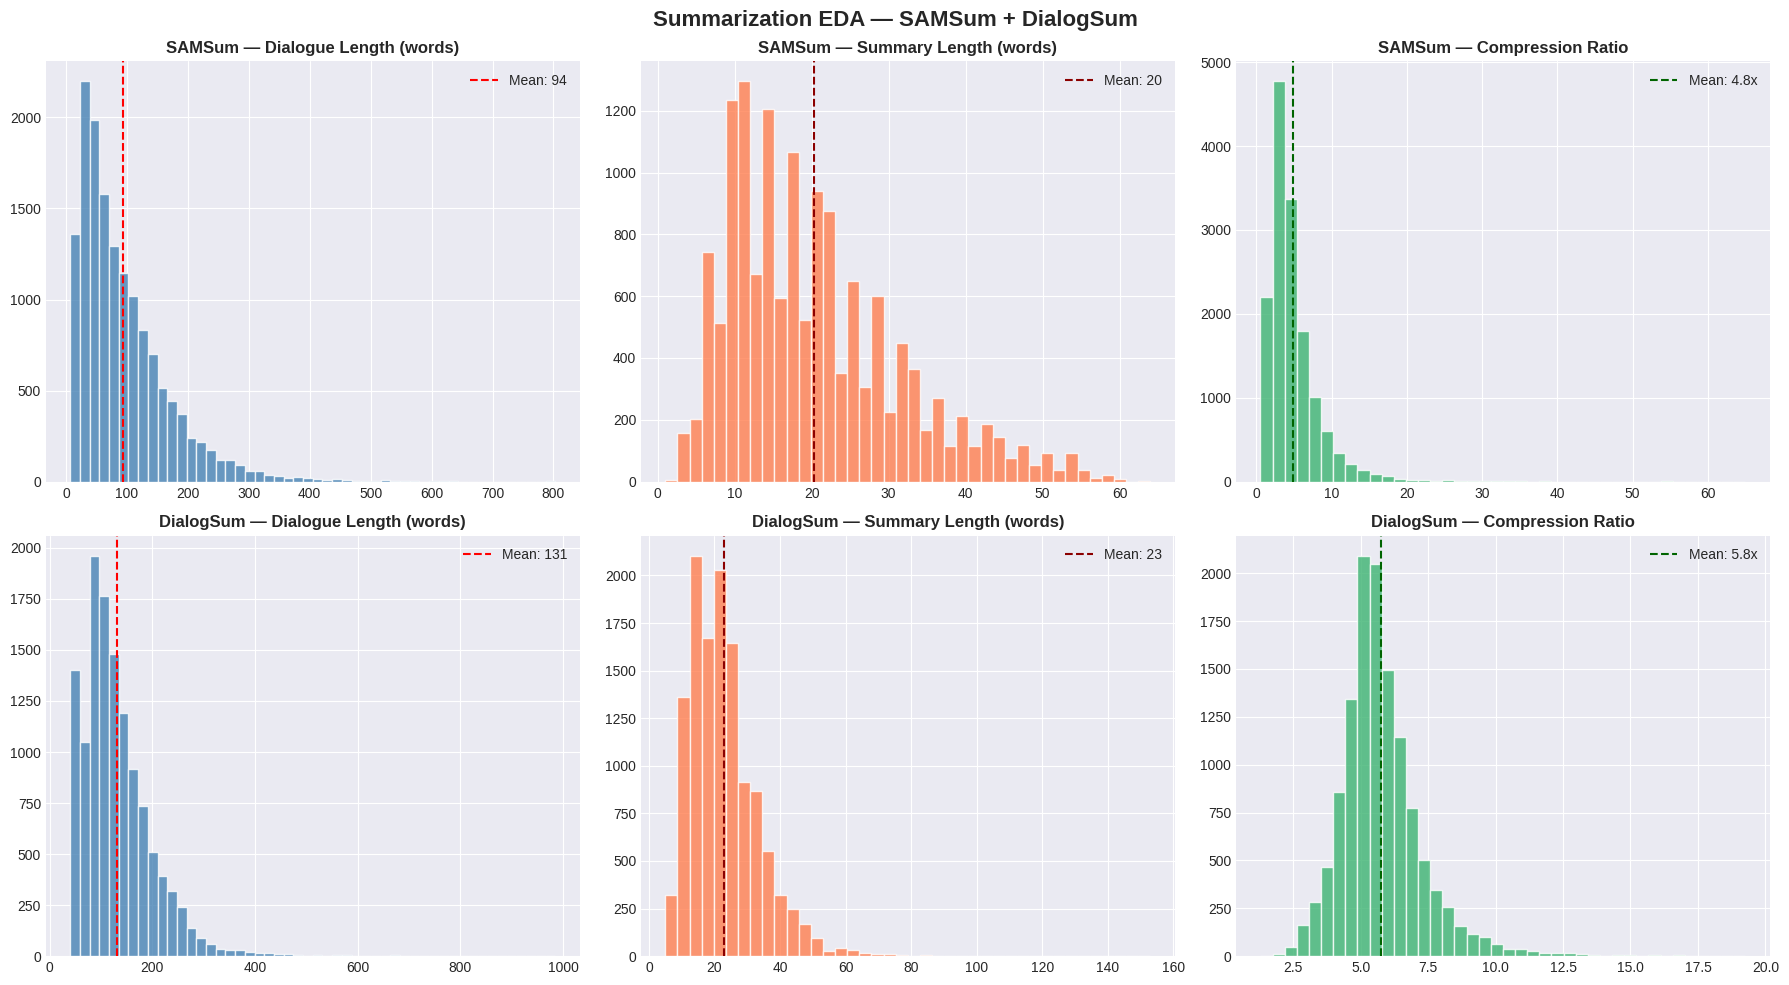

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (df, name) in enumerate([(df_sam, "SAMSum"), (df_dia, "DialogSum")]):
    axes[row][0].hist(df["dialogue_len"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
    axes[row][0].set_title(f"{name} — Dialogue Length (words)", fontweight="bold")
    axes[row][0].axvline(df["dialogue_len"].mean(), color="red", linestyle="--",
                         label=f"Mean: {df['dialogue_len'].mean():.0f}")
    axes[row][0].legend()

    axes[row][1].hist(df["summary_len"], bins=40, color="coral", alpha=0.8, edgecolor="white")
    axes[row][1].set_title(f"{name} — Summary Length (words)", fontweight="bold")
    axes[row][1].axvline(df["summary_len"].mean(), color="darkred", linestyle="--",
                         label=f"Mean: {df['summary_len'].mean():.0f}")
    axes[row][1].legend()

    axes[row][2].hist(df["compression"], bins=40, color="mediumseagreen", alpha=0.8, edgecolor="white")
    axes[row][2].set_title(f"{name} — Compression Ratio", fontweight="bold")
    axes[row][2].axvline(df["compression"].mean(), color="darkgreen", linestyle="--",
                         label=f"Mean: {df['compression'].mean():.1f}x")
    axes[row][2].legend()

plt.suptitle("Summarization EDA — SAMSum + DialogSum", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE_DIR / "summarization_eda.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 Data Cleaning & Merging

In [7]:
def clean_summ_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\n+", " \n ", text).strip()
    text = re.sub(r" +", " ", text)
    return text

def clean_summ_split(dataset_split, max_diag_words=800, max_summ_words=150):
    df = pd.DataFrame(dataset_split)[["dialogue", "summary"]]
    orig = len(df)
    df["dialogue"] = df["dialogue"].apply(clean_summ_text)
    df["summary"]  = df["summary"].apply(clean_summ_text)
    df = df[df["dialogue"].str.len() > 10].reset_index(drop=True)
    df = df[df["summary"].str.len() > 5].reset_index(drop=True)
    df["dw"] = df["dialogue"].str.split().str.len()
    df["sw"] = df["summary"].str.split().str.len()
    df = df[(df["dw"] <= max_diag_words) & (df["sw"] <= max_summ_words)].reset_index(drop=True)
    df = df.drop(columns=["dw", "sw"])
    print(f"  {orig} -> {len(df)} samples")
    return Dataset.from_pandas(df)

In [8]:
sam_train = clean_summ_split(ds_samsum["train"])
sam_val   = clean_summ_split(ds_samsum["validation"])
sam_test  = clean_summ_split(ds_samsum["test"])

dia_train = clean_summ_split(ds_dialogsum["train"])
dia_val   = clean_summ_split(ds_dialogsum["validation"])
dia_test  = clean_summ_split(ds_dialogsum["test"])

ds_summ = DatasetDict({
    "train":      concatenate_datasets([sam_train, dia_train]),
    "validation": concatenate_datasets([sam_val,   dia_val]),
    "test":       concatenate_datasets([sam_test,  dia_test]),
})

print(ds_summ)

  14731 -> 14728 samples
  818 -> 818 samples
  819 -> 819 samples
  12460 -> 12458 samples
  500 -> 500 samples
  1500 -> 1500 samples
DatasetDict({
    train: Dataset({
        features: ['dialogue', 'summary'],
        num_rows: 27186
    })
    validation: Dataset({
        features: ['dialogue', 'summary'],
        num_rows: 1318
    })
    test: Dataset({
        features: ['dialogue', 'summary'],
        num_rows: 2319
    })
})


## 3.4 Tokenization with BART

In [9]:
SUMM_MODEL_NAME = "facebook/bart-base"
print(f"Loading tokenizer: {SUMM_MODEL_NAME}")

summ_tokenizer = AutoTokenizer.from_pretrained(SUMM_MODEL_NAME, use_fast=True)

MAX_SRC = 512
MAX_TGT = 128

def tokenize_summ(examples):
    model_inputs = summ_tokenizer(
        examples["dialogue"],
        max_length=MAX_SRC,
        truncation=True,
        padding="max_length"
    )
    labels = summ_tokenizer(
        text_target=examples["summary"],
        max_length=MAX_TGT,
        truncation=True,
        padding="max_length"
    )
    labels["input_ids"] = [
        [(token if token != summ_tokenizer.pad_token_id else -100) for token in label]
        for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

ds_summ_tok = ds_summ.map(
    tokenize_summ,
    batched=True,
    remove_columns=["dialogue", "summary"],
    desc="Tokenizing for BART"
)
ds_summ_tok.set_format("torch")
print(ds_summ_tok)

Loading tokenizer: facebook/bart-base


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing for BART:   0%|          | 0/27186 [00:00<?, ? examples/s]

Tokenizing for BART:   0%|          | 0/1318 [00:00<?, ? examples/s]

Tokenizing for BART:   0%|          | 0/2319 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 27186
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1318
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2319
    })
})


## 3.5 Fine-Tuning BART-base

In [10]:
summ_model = AutoModelForSeq2SeqLM.from_pretrained(SUMM_MODEL_NAME)
summ_model.to(DEVICE)

total_summ = sum(p.numel() for p in summ_model.parameters())
print(f"{SUMM_MODEL_NAME} — {total_summ:,} params")

ds_summ_tok["train"] = ds_summ_tok["train"].shuffle(seed=42).select(range(13000))
ds_summ_tok["validation"] = ds_summ_tok["validation"].shuffle(seed=42).select(range(1000))

print(f"Train: {len(ds_summ_tok['train']):,} | Val: {len(ds_summ_tok['validation']):,}")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

facebook/bart-base — 139,420,416 params
Train: 13,000 | Val: 1,000


In [11]:
num_training_steps = (len(ds_summ_tok["train"]) // 8) * 3
warmup_steps = int(0.1 * num_training_steps)

summ_training_args = TrainingArguments(
    output_dir=str(SUMM_DIR),
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
    prediction_loss_only=True,
)

In [12]:
summ_trainer = Trainer(
    model=summ_model,
    args=summ_training_args,
    train_dataset=ds_summ_tok["train"],
    eval_dataset=ds_summ_tok["validation"],
    data_collator=DataCollatorForSeq2Seq(summ_tokenizer, model=summ_model, pad_to_multiple_of=8),
    compute_metrics=None,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

summ_train_result = summ_trainer.train()

print(f"Loss: {summ_train_result.training_loss:.4f}")
print(f"Runtime: {summ_train_result.metrics['train_runtime']:.0f}s")

Step,Training Loss,Validation Loss
1000,1.658778,1.521311
2000,1.402010,1.452820
3000,1.350139,1.420749
4000,1.146822,1.399220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Loss: 1.4293
Runtime: 1396s


## 3.6 Testing & Evaluation — Summarization

In [13]:
print("Evaluating BART on TEST set...")
summ_test_results = summ_trainer.evaluate(ds_summ_tok["test"])

print("\nSummarization Test Results:")
for k, v in summ_test_results.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

Evaluating BART on TEST set...



Summarization Test Results:
  eval_loss: 1.4694
  eval_runtime: 27.0239
  eval_samples_per_second: 85.8130
  eval_steps_per_second: 42.9250
  epoch: 3.0000


In [14]:
rouge_hist = [
    (e["epoch"], e.get("eval_rouge1"), e.get("eval_rouge2"), e.get("eval_rougeL"))
    for e in summ_trainer.state.log_history
    if "eval_rouge1" in e
]

if rouge_hist:
    ep, r1, r2, rL = zip(*rouge_hist)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(ep, r1, "o-", label="ROUGE-1", linewidth=2)
    ax.plot(ep, r2, "s--", label="ROUGE-2", linewidth=2)
    ax.plot(ep, rL, "^:", label="ROUGE-L", linewidth=2)
    ax.set_title("BART Summarization — ROUGE Scores per Epoch", fontsize=14, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("ROUGE Score")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(BASE_DIR / "summ_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("ROUGE history not available (metrics disabled during training)")

ROUGE history not available (metrics disabled during training)


In [15]:
def summarize(text):
    inputs = summ_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    ).to(DEVICE)
    outputs = summ_model.generate(
        **inputs, max_length=80, min_length=20, num_beams=4, early_stopping=True
    )
    return summ_tokenizer.decode(outputs[0], skip_special_tokens=True)

meeting_dialogue = """
Alice: Morning team! Let's kick off our sprint review. John, can you walk us through the backend progress?
John: Sure. We've completed the user authentication API and the database migration. There were some delays with the payment gateway integration due to a third-party API issue.
Alice: Got it. Sarah, what's the status on the frontend?
Sarah: The dashboard and profile pages are done. The notifications module is 80% complete, should be ready by Thursday.
Alice: Great. Any blockers?
John: We need the design specs for the admin panel before we can start that.
Sarah: I'll follow up with the design team today.
Alice: Perfect. Let's schedule a follow-up on Friday to review the payment gateway fix. Mark it as high priority.
"""

summary = summarize(meeting_dialogue.strip())
print(f"Original ({len(meeting_dialogue.split())} words):")
print(meeting_dialogue.strip()[:300])
print(f"\nSummary: {summary}")

Original (121 words):
Alice: Morning team! Let's kick off our sprint review. John, can you walk us through the backend progress?
John: Sure. We've completed the user authentication API and the database migration. There were some delays with the payment gateway integration due to a third-party API issue.
Alice: Got it. Sa

Summary: Alice, John and Sarah are going to kick off their sprint review. John has completed the user authentication API and the database migration. Sarah will follow up with the design team on Friday to review the payment gateway fix.


## 3.7 Save Summarization Model

In [16]:
summ_trainer.save_model(str(SUMM_DIR))
summ_tokenizer.save_pretrained(str(SUMM_DIR))
print(f"Summarization model saved to: {SUMM_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Summarization model saved to: nlu_models/summarizer
